# Grid Search Analysis

Visualize results from the (σ₀, σ, η) parameter sweep.
Loads pre-computed per-triple `.npz` files and the gathered CSV/grid arrays.

Plots:
1. d' heatmaps (two slice orientations)
2. ISI decay curves for triples with strongest memory decay
3. ROC curves per ISI for selected triples
4. Hit vs FA score distributions
5. Parameter sensitivity (marginal d' curves)
6. Temporal dynamics (hit score vs trial position)

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Point this to your grid search output directory ──
RESULTS_DIR = '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/2d_grid_search/slurm_20260317'

# Load grid arrays
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results.npz'))
sigma0_grid = grid['sigma0_grid']
sigma_grid = grid['sigma_grid']
eta_grid = grid['eta_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# Load master CSV
df = pd.read_csv(os.path.join(RESULTS_DIR, 'grid_search_master.csv'))

PER_TRIPLE_DIR = os.path.join(RESULTS_DIR, 'per_triple')

def load_triple(s0, sig, eta):
    fname = f's0={s0:.3f}_sig={sig:.3f}_eta={eta:.3f}.npz'
    return np.load(os.path.join(PER_TRIPLE_DIR, fname), allow_pickle=True)

print(f'Grid: {len(sigma0_grid)} x {len(sigma_grid)} x {len(eta_grid)} = {len(df)} triples')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma:  {sigma_grid}')
print(f'eta:    {eta_grid}')


## Human-like memory decay ranking (avoid extreme ceiling/floor behavior)

Instead of ranking only by \(\Delta d' = d'(\mathrm{ISI}=0) - d'(\mathrm{ISI}=16)\), this section adds:

- **Early decay strength**: larger drop from ISI=0 to ISI=2.
- **Late plateau preference**: small change between ISI=8 and ISI=16.
- **Extreme-behavior penalty**: penalize near-perfect ISI=0 and near-chance ISI=16.

This keeps strong memory degradation while favoring more human-like trajectories.


In [ ]:
def zscore(s):
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

work = df.copy()
work['delta_total'] = work['dprime_isi0'] - work['dprime_isi16']
work['delta_early'] = work['dprime_isi0'] - work['dprime_isi2']
work['delta_late'] = work['dprime_isi8'] - work['dprime_isi16']

# Penalize extreme ceiling/floor behavior
work['penalty_extreme'] = np.maximum(work['dprime_isi0'] - 3.0, 0) + np.maximum(0.3 - work['dprime_isi16'], 0)

# Composite score (higher is better)
work['decay_score'] = (
    1.0 * zscore(work['delta_total']) +
    0.8 * zscore(work['delta_early']) -
    0.8 * zscore(work['delta_late'].abs()) -
    1.2 * zscore(work['penalty_extreme'])
)

# Mild quality filter to remove pathological curves
interesting = work[(work['dprime_isi0'] > 0.4) & (work['delta_total'] > 0.1)].copy()
top = interesting.nlargest(10, 'decay_score').reset_index(drop=True)

print(f'{len(interesting)} interesting triples (of {len(df)} total)')
print('Top triples by human-like decay score:')
print(top[[
    'sigma0', 'sigma', 'eta',
    'dprime_isi0', 'dprime_isi2', 'dprime_isi8', 'dprime_isi16',
    'delta_total', 'delta_early', 'delta_late', 'penalty_extreme', 'decay_score'
]].to_string(index=False))

isi_arr = np.array(ISI_VALUES)
colors = plt.cm.tab10(np.linspace(0, 1, len(top)))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i, row in top.iterrows():
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])
    dps = [float(data[f'dprime_isi{isi}']) for isi in ISI_VALUES]
    sems = [float(data[f'dprime_sem_isi{isi}']) for isi in ISI_VALUES]
    label = (
        f"σ₀={row['sigma0']:.2f}, σ={row['sigma']:.3f}, η={row['eta']:.3f} "
        f"(score={row['decay_score']:.2f})"
    )
    ax.errorbar(isi_arr, dps, yerr=sems, marker='o', capsize=3,
                color=colors[i], label=label, linewidth=1.8)

ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("d'", fontsize=12)
ax.set_title("Selected triples with strong, human-like memory decay", fontsize=13)
ax.set_xticks(isi_arr)
ax.legend(fontsize=7, loc='best')
fig.tight_layout()
plt.show()


## ROC Curves for Selected Triples


In [ ]:
isi_colors = {0: 'green', 2: 'blue', 8:'red', 16: 'orange'}
top = top_band.nlargest(6, col)
n_triples = min(len(top), 6)
ncols = 3
nrows = int(np.ceil(n_triples / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.atleast_2d(axes)

for idx, (_, row) in enumerate(top.head(n_triples).iterrows()):
    ax = axes.flat[idx]
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])
    for isi in ISI_VALUES:
        fpr = data[f'roc_fpr_isi{isi}']
        tpr = data[f'roc_tpr_isi{isi}']
        auc = float(data[f'auc_isi{isi}'])
        if len(fpr) > 0:
            ax.plot(fpr, tpr, color=isi_colors[isi], linewidth=2,
                    label=f'ISI={isi} (AUC={auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.5)
    ax.set_title(f'\u03c3\u2080={row["sigma0"]:.2f}, \u03c3={row["sigma"]:.3f}, \u03b7={row["eta"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

# Hide unused axes
for idx in range(n_triples, nrows * ncols):
    axes.flat[idx].set_visible(False)

fig.suptitle('ROC Curves per ISI (top percentile triples)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Score Distributions: Hit vs FA


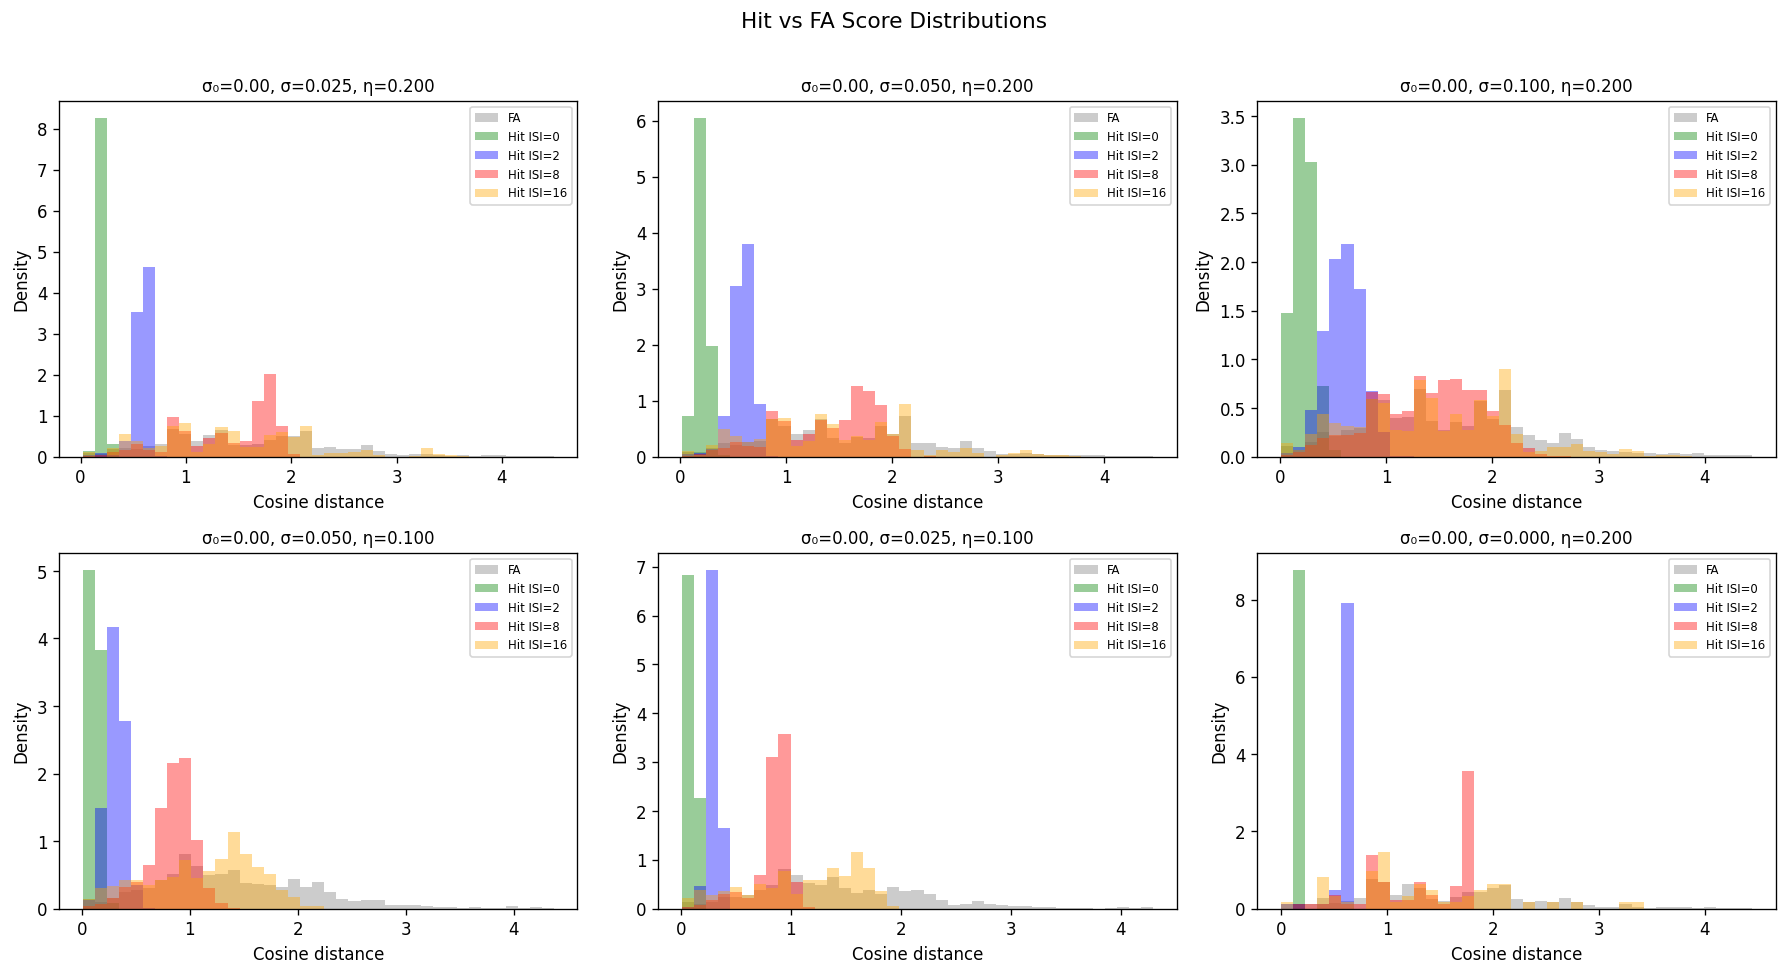

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, (_, row) in enumerate(top.head(n_triples).iterrows()):
    ax = axes.flat[idx]
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])
    fa = data['fa_scores']

    # Determine bin range across all scores
    all_scores = [fa]
    for isi in ISI_VALUES:
        h = data[f'hit_scores_isi{isi}']
        if len(h) > 0:
            all_scores.append(h)
    combined = np.concatenate(all_scores)
    bins = np.linspace(np.percentile(combined, 1), np.percentile(combined, 99), 40)

    ax.hist(fa, bins=bins, alpha=0.4, color='gray', label='FA', density=True)
    for isi, color in isi_colors.items():
        h = data[f'hit_scores_isi{isi}']
        if len(h) > 0:
            ax.hist(h, bins=bins, alpha=0.4, color=color,
                    label=f'Hit ISI={isi}', density=True)

    ax.set_title(f'\u03c3\u2080={row["sigma0"]:.2f}, \u03c3={row["sigma"]:.3f}, \u03b7={row["eta"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Euclidean distance')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for idx in range(n_triples, nrows * ncols):
    axes.flat[idx].set_visible(False)

fig.suptitle('Hit vs FA Score Distributions', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## Temporal Dynamics: Hit Score vs Trial Position (Euclidean distance)


In [ ]:
# Use the top-1 ranked triple from the human-like decay score
row = top.iloc[0]
data = load_triple(row['sigma0'], row['sigma'], row['eta'])

fig, ax = plt.subplots(figsize=(8, 5))
for isi, color in isi_colors.items():
    scores = data[f'hit_scores_isi{isi}']
    times = data[f'hit_timestamps_isi{isi}']
    if len(scores) == 0:
        continue

    ax.scatter(times, scores, alpha=0.3, s=15, color=color, label=f'ISI={isi}')

    if len(scores) > 5:
        order = np.argsort(times)
        t_sorted = times[order].astype(float)
        s_sorted = scores[order]
        window = max(len(s_sorted) // 10, 5)
        kernel = np.ones(window) / window
        smoothed = np.convolve(s_sorted, kernel, mode='valid')
        t_smooth = np.convolve(t_sorted, kernel, mode='valid')
        ax.plot(t_smooth, smoothed, color=color, linewidth=2, alpha=0.85)

ax.set_xlabel('Trial position', fontsize=12)
ax.set_ylabel('Hit score (euclidean distance)', fontsize=12)
ax.set_title(
    f"Temporal dynamics: σ₀={row['sigma0']:.2f}, σ={row['sigma']:.3f}, η={row['eta']:.3f}",
    fontsize=13
)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()


## Single-ISI follow-up (ISI=16): item-wise HR/FAR + d' vs nearest-prior-mode distance

For each selected triple, this section loads ISI=16-only outputs and summarizes:

- hit rate (HR) and false alarm rate (FAR),
- item-wise HR/FAR if item IDs are present,
- a scatter of **d' (y-axis)** vs **mean nearest-prior-mode distance (x-axis)**.

This makes it easier to inspect the relationship between representational distance and recognition quality.


In [ ]:
TARGET_ISI = 16
if TARGET_ISI not in ISI_VALUES:
    raise ValueError(f'ISI={TARGET_ISI} is not in this grid: {ISI_VALUES}')

rows = []
item_tables = {}

for i, row in top.iterrows():
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])

    hit = np.asarray(data[f'hit_scores_isi{TARGET_ISI}'])
    fa = np.asarray(data['fa_scores'])

    # Conservative binary decision around zero-distance boundary.
    # (Adjust threshold if your score convention differs.)
    threshold = 0.0
    hr = np.mean(hit > threshold) if hit.size else np.nan
    far = np.mean(fa > threshold) if fa.size else np.nan

    rows.append({
        'rank': i + 1,
        'sigma0': row['sigma0'],
        'sigma': row['sigma'],
        'eta': row['eta'],
        f'dprime_isi{TARGET_ISI}': float(data[f'dprime_isi{TARGET_ISI}']),
        'mean_hit_distance': float(np.mean(hit)) if hit.size else np.nan,
        'mean_fa_distance': float(np.mean(fa)) if fa.size else np.nan,
        'hr': hr,
        'far': far,
    })

    # Optional item-level breakdown if item IDs were saved in the npz
    hit_id_key = f'hit_item_ids_isi{TARGET_ISI}'
    fa_id_key = 'fa_item_ids'
    if hit_id_key in data.files and fa_id_key in data.files:
        hit_ids = np.asarray(data[hit_id_key])
        fa_ids = np.asarray(data[fa_id_key])

        hit_df = pd.DataFrame({'item_id': hit_ids, 'hit_score': hit})
        fa_df = pd.DataFrame({'item_id': fa_ids, 'fa_score': fa})

        hit_item = hit_df.groupby('item_id', as_index=False).agg(
            n_hit=('hit_score', 'size'),
            hit_rate=('hit_score', lambda x: np.mean(x > threshold)),
            mean_hit_distance=('hit_score', 'mean'),
        )
        fa_item = fa_df.groupby('item_id', as_index=False).agg(
            n_fa=('fa_score', 'size'),
            fa_rate=('fa_score', lambda x: np.mean(x > threshold)),
            mean_fa_distance=('fa_score', 'mean'),
        )

        item_tables[i + 1] = hit_item.merge(fa_item, on='item_id', how='outer')

single_isi_df = pd.DataFrame(rows)
display(single_isi_df.sort_values(f'dprime_isi{TARGET_ISI}', ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(single_isi_df['mean_hit_distance'],
           single_isi_df[f'dprime_isi{TARGET_ISI}'],
           s=60, alpha=0.9)

for _, r in single_isi_df.iterrows():
    ax.annotate(str(int(r['rank'])),
                (r['mean_hit_distance'], r[f'dprime_isi{TARGET_ISI}']),
                xytext=(5, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Mean nearest-prior-mode distance (hits, ISI=16)')
ax.set_ylabel("d' (ISI=16)")
ax.set_title("Single-ISI analysis: d' vs nearest-prior-mode distance")
fig.tight_layout()
plt.show()

if item_tables:
    print('Item-wise HR/FAR tables are available in `item_tables` (dict keyed by rank).')
    first_key = sorted(item_tables.keys())[0]
    print(f'Preview for rank {first_key}:')
    display(item_tables[first_key].head())
else:
    print('No item ID arrays were found in the per-triple files; item-wise HR/FAR table skipped.')
